In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

perf = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [4]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


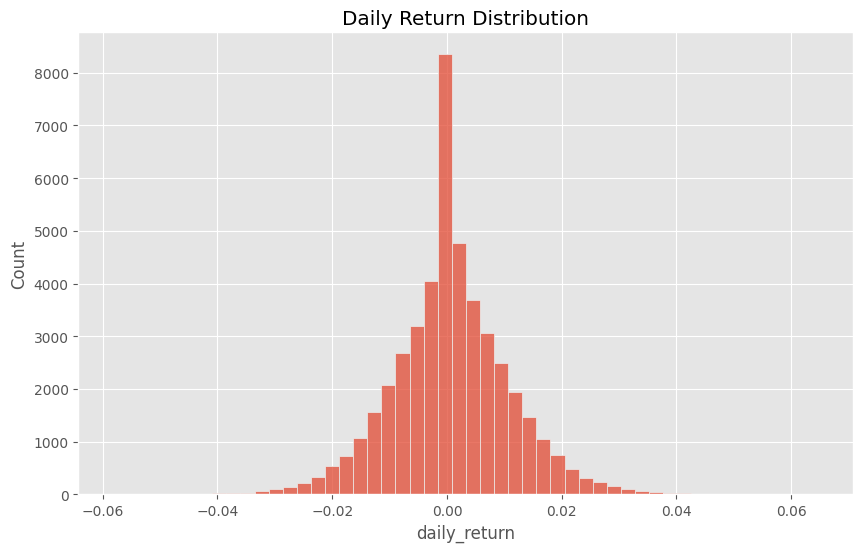

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.show()

In [6]:
def cagr(start, end, years):
    return (end/start)**(1/years)-1

In [7]:
cagr_table = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    years = (
        (df["date"].max() -
         df["date"].min()).days
        /365
    )

    value = cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_table.append(
        [code,value]
    )

cagr_df = pd.DataFrame(
    cagr_table,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [8]:
rf = 0.065

sharpe_list = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"]==code
    ]["daily_return"].dropna()

    sharpe = (
        (returns.mean()*252-rf)
        /
        (returns.std()*np.sqrt(252))
    )

    sharpe_list.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [9]:
sortino_list = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"]==code
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    sortino = (
        (returns.mean()*252-rf)
        /
        (downside.std()*np.sqrt(252))
    )

    sortino_list.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [10]:
drawdowns = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"]==code
    ].copy()

    df["running_max"] = (
        df["nav"]
        .cummax()
    )

    df["drawdown"] = (
        df["nav"]
        /
        df["running_max"]
        -1
    )

    max_dd = (
        df["drawdown"]
        .min()
    )

    drawdowns.append(
        [code,max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [11]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [12]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [13]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [40]:
nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty = nifty.sort_values("date")

nifty["benchmark_return"] = (
    nifty["close_value"]
    .pct_change()
)
print(nifty.shape)
nifty.head()

(1150, 4)


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [42]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty[["date","benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 20:
        continue

    slope, intercept, r, p, std = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = slope
    alpha = intercept * 252

    alpha_beta.append(
        [code, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [43]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [44]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(sortino_df)
    .merge(drawdown_df)
    .merge(alpha_beta_df)
)

In [48]:
print(scorecard.shape)
scorecard.head()

(40, 12)


,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
34,148567,0.309499,1.448291,2.385644,-0.112657,0.269838,0.023684,5.0,1.0,7.0,8.0,5.15
30,120843,0.308833,1.306744,2.364320,-0.129740,0.273305,-0.022830,6.0,2.0,5.0,13.0,6.55
36,148569,0.319245,1.234930,2.146914,-0.163967,0.282704,0.018134,4.0,3.0,4.0,21.0,8.00
25,120505,0.328016,1.180101,2.029353,-0.181885,0.292636,0.000549,1.0,5.0,3.0,25.0,8.40
2,100033,0.300997,1.093699,1.829134,-0.162172,0.271954,0.005104,7.0,7.0,6.0,20.0,10.05


In [45]:
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [46]:
scorecard["fund_score"] = (
    0.30*scorecard["return_rank"] +
    0.25*scorecard["sharpe_rank"] +
    0.20*scorecard["alpha_rank"] +
    0.25*scorecard["dd_rank"]
)

scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
34,148567,0.309499,1.448291,2.385644,-0.112657,0.269838,0.023684,5.0,1.0,7.0,8.0,5.15
30,120843,0.308833,1.306744,2.364320,-0.129740,0.273305,-0.022830,6.0,2.0,5.0,13.0,6.55
36,148569,0.319245,1.234930,2.146914,-0.163967,0.282704,0.018134,4.0,3.0,4.0,21.0,8.00
25,120505,0.328016,1.180101,2.029353,-0.181885,0.292636,0.000549,1.0,5.0,3.0,25.0,8.40
2,100033,0.300997,1.093699,1.829134,-0.162172,0.271954,0.005104,7.0,7.0,6.0,20.0,10.05
19,119551,0.257849,1.208267,2.140267,-0.150124,0.232010,-0.031751,10.0,4.0,10.0,17.0,10.25
3,101206,0.235205,1.027213,1.799563,-0.112916,0.213998,0.021086,12.0,9.0,12.0,9.0,10.50
38,149323,0.295581,1.132122,1.875101,-0.172481,0.265986,-0.002523,8.0,6.0,8.0,22.0,11.00
24,120504,0.232774,1.026524,1.805294,-0.125883,0.211948,0.016232,13.0,10.0,13.0,12.0,12.00
9,118632,0.240312,1.081659,1.850133,-0.174141,0.218294,-0.008354,11.0,8.0,11.0,23.0,13.25


In [47]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [56]:
top5

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score


In [57]:
print(top5.shape)

(0, 12)


In [58]:
scorecard[["amfi_code","cagr","fund_score"]].head()

,amfi_code,cagr,fund_score
34,148567,0.309499,4.5
30,120843,0.308833,5.3
36,148569,0.319245,5.4
25,120505,0.328016,5.0
2,100033,0.300997,8.1


In [59]:
top5 = scorecard.nsmallest(5, "fund_score")
top5

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
34,148567,0.309499,1.448291,2.385644,-0.112657,0.269838,0.023684,5.0,1.0,7.0,8.0,4.5
25,120505,0.328016,1.180101,2.029353,-0.181885,0.292636,0.000549,1.0,5.0,3.0,25.0,5.0
30,120843,0.308833,1.306744,2.364320,-0.129740,0.273305,-0.022830,6.0,2.0,5.0,13.0,5.3
36,148569,0.319245,1.234930,2.146914,-0.163967,0.282704,0.018134,4.0,3.0,4.0,21.0,5.4
2,100033,0.300997,1.093699,1.829134,-0.162172,0.271954,0.005104,7.0,7.0,6.0,20.0,8.1


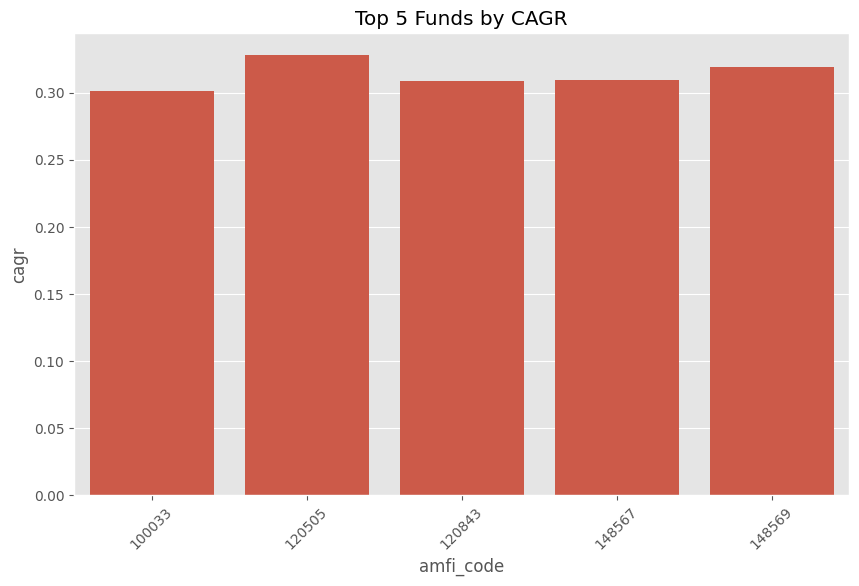

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top5,
    x="amfi_code",
    y="cagr"
)

plt.title("Top 5 Funds by CAGR")
plt.xticks(rotation=45)

plt.show()

In [62]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [63]:
print(scorecard.shape)
scorecard.head()

(40, 12)


,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
34,148567,0.309499,1.448291,2.385644,-0.112657,0.269838,0.023684,5.0,1.0,7.0,8.0,4.5
30,120843,0.308833,1.306744,2.364320,-0.129740,0.273305,-0.022830,6.0,2.0,5.0,13.0,5.3
36,148569,0.319245,1.234930,2.146914,-0.163967,0.282704,0.018134,4.0,3.0,4.0,21.0,5.4
25,120505,0.328016,1.180101,2.029353,-0.181885,0.292636,0.000549,1.0,5.0,3.0,25.0,5.0
2,100033,0.300997,1.093699,1.829134,-0.162172,0.271954,0.005104,7.0,7.0,6.0,20.0,8.1


In [24]:
print(top5.shape)
top5

(0, 12)


,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score


In [26]:
print(scorecard.shape)

(0, 12)


In [27]:
scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score


In [28]:
print(top5.shape)

(0, 12)


In [29]:
top5

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score


In [30]:
nav.columns


Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')

In [31]:
nav[["date","amfi_code"]].head()

,date,amfi_code
0,2022-01-03,100016
1,2022-01-04,100016
2,2022-01-05,100016
3,2022-01-06,100016
4,2022-01-07,100016


In [32]:
nifty[["date"]].head()

,date


In [33]:
code = nav["amfi_code"].unique()[0]

fund_data = nav[
    nav["amfi_code"] == code
][["date","daily_return"]]

merged = pd.merge(
    fund_data,
    nifty[["date","benchmark_return"]],
    on="date",
    how="inner"
)

print(len(fund_data))
print(len(nifty))
print(len(merged))

merged.head()

1150
0
0


,date,daily_return,benchmark_return


In [34]:
print(benchmark.shape)
benchmark.head()

(8050, 3)


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [35]:
print(nifty.shape)
nifty.head()

(0, 4)


,date,index_name,close_value,benchmark_return


In [36]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [50]:
scorecard.columns

Index(['amfi_code', 'cagr', 'sharpe_ratio', 'sortino_ratio', 'max_drawdown',
       'alpha', 'beta', 'return_rank', 'sharpe_rank', 'alpha_rank', 'dd_rank',
       'fund_score'],
      dtype='object')

In [51]:
scorecard["fund_score"] = (
    0.40 * scorecard["return_rank"] +
    0.30 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.10 * scorecard["dd_rank"]
)

In [52]:
scorecard.sort_values(
    "fund_score"
).head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,alpha,beta,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
34,148567,0.309499,1.448291,2.385644,-0.112657,0.269838,0.023684,5.0,1.0,7.0,8.0,4.5
25,120505,0.328016,1.180101,2.029353,-0.181885,0.292636,0.000549,1.0,5.0,3.0,25.0,5.0
30,120843,0.308833,1.306744,2.364320,-0.129740,0.273305,-0.022830,6.0,2.0,5.0,13.0,5.3
36,148569,0.319245,1.234930,2.146914,-0.163967,0.282704,0.018134,4.0,3.0,4.0,21.0,5.4
2,100033,0.300997,1.093699,1.829134,-0.162172,0.271954,0.005104,7.0,7.0,6.0,20.0,8.1


In [53]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [54]:
scorecard.columns

Index(['amfi_code', 'cagr', 'sharpe_ratio', 'sortino_ratio', 'max_drawdown',
       'alpha', 'beta', 'return_rank', 'sharpe_rank', 'alpha_rank', 'dd_rank',
       'fund_score'],
      dtype='object')

In [55]:
len(scorecard)

40